# 🤖 IT Helpdesk AI Assistant — Domain-Specific LLM Fine-Tuning
### Built with Unsloth | Qwen2.5-1.5B | LoRA/QLoRA | SFT + DPO Alignment
---
## Stage 1: Non-Instruction Fine-Tuning (Continued Pretraining)
---
**Dataset:** [Tobi-Bueck/customer-support-tickets](https://huggingface.co/datasets/Tobi-Bueck/customer-support-tickets) (HuggingFace) — 61.8k IT support tickets
**Base Model:** unsloth/Qwen2.5-1.5B  
**This Notebook Covers:** Loading raw domain text → Cleaning & building the `text` column → Loading base model via Unsloth → Applying LoRA (QLoRA) → Training on raw domain text → Saving adapter → Testing text continuation  
**Hardware:** NVIDIA T4 (Google Colab / Kaggle Free GPU)  

---
> **Business Problem:** Build an internal IT support assistant that understands domain-specific  
> terminology, triages tickets accurately, and gives precise resolutions — outperforming a  
> generic base model on real helpdesk queries.
>
> **Goal of this stage:** Adapt the base model to IT-support vocabulary, ticket structure, and  
> writing style *before* instruction fine-tuning — teaching it to "think" in domain language.

## Install the required libraries

In [ ]:
!pip install unsloth datasets huggingface_hub -q 

In [71]:
%cd /content/drive/MyDrive/Fine-Tuning-Assignment

/content/drive/MyDrive/Fine-Tuning-Assignment


In [87]:
# create directories needed further
os.makedirs("data", exist_ok=True)

## Import required libraries and packages

In [126]:
import os
import re
import torch
import warnings
import pandas as pd
from typing import List
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
from huggingface_hub import login, HfApi
from datasets import Dataset, load_dataset
from unsloth import FastLanguageModel, is_bfloat16_supported, UnslothTrainer, UnslothTrainingArguments
warnings.filterwarnings("ignore")

In [117]:
@dataclass
class Config:
  huggingface_dataset = "Tobi-Bueck/customer-support-tickets"
  llm_model = ""
  filepath_for_cpt_data = "data/non_instruction_data.txt"
  # Model
  model_name: str = "unsloth/Qwen2.5-1.5B"
  max_seq_length: int = 2048
  dtype: str = None  # auto-detect
  load_in_4bit: bool = True

  # LoRA
  lora_r: int = 16
  lora_alpha: int = 16
  lora_dropout: float = 0.0
  target_modules: List[str] = field(default_factory=lambda: [
      "q_proj", "k_proj", "v_proj", "o_proj",
      "gate_proj", "up_proj", "down_proj",
      "embed_tokens", "lm_head",
  ])
  bias: str = "none"
  use_gradient_checkpointing: str = "unsloth"
  random_state: int = 42

  # Training
  per_device_train_batch_size: int = 4
  gradient_accumulation_steps: int = 4
  warmup_ratio: float = 0.1
  num_train_epochs: int = 3
  learning_rate: float = 5e-5
  embedding_learning_rate: float = 5e-6
  logging_steps: int = 10
  optim: str = "adamw_8bit"
  output_dir: str = "outputs/cpt"

cfg = Config()

## Logging into HuggingFace Hub

In [74]:
# log in huggingface hub
login()

# Creation on the Non Instruction Fine Tuning Dataset

## Load the hugging face dataset.

In [75]:
dataset = load_dataset(Config.huggingface_dataset)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})


In [76]:
df = dataset["train"].to_pandas()

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Languages: {df['language'].value_counts()}")
print(f"Types: {df['type'].value_counts()}")

Shape: (61765, 16)
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']
Languages: language
de    33504
en    28261
Name: count, dtype: int64
Types: type
Incident    19444
Request     13950
Problem     10196
Change       4997
Name: count, dtype: int64


In [77]:
# only select those rows where the language is en (English)
df = df[df['language'] == 'en']

# drop rows where the core data columns are missing
df.dropna(subset=["subject", "body", "answer"],inplace=True)

In [78]:
def clean_text(text):
    """Cleans a single text field: placeholders, escaped newlines, whitespace."""
    if pd.isna(text):
        return ""

    text = str(text)

    # Remove HTML leftover
    text = text.replace("<br>", " ")

    # Replace anonymization placeholders with natural language
    text = text.replace("<name>", "the user")
    text = text.replace("<tel_num>", "a phone number")
    text = text.replace("<acc_num>", "an account number")
    text = text.replace("<email>", "an email address")
    text = text.replace("<website_url>", "a website link")
    text = text.replace("<user>", "the user")

    # Replace literal "\n" (backslash-n) and real newline characters
    text = text.replace("\\n", " ").replace("\n", " ")

    # Collapse multiple spaces into one
    text = " ".join(text.split())

    return text.strip()

In [79]:
def build_text(row):
    """Builds the final CPT text document for one ticket row."""
    body = clean_text(row["body"])
    answer = clean_text(row["answer"])

    # Filter out short/low-quality entries
    if len(body) < 100 or len(answer) < 100:
        return None

    # Filter out truncated entries
    if body.endswith("...") or answer.endswith("..."):
        return None

    tags = [row.get(f"tag_{i}") for i in range(1, 6)]
    tags = [t for t in tags if pd.notna(t)]
    tag_str = ", ".join(tags) if tags else "General"

    return (
        f"Support Ticket — Queue: {row['queue']} | Type: {row['type']} | "
        f"Priority: {row['priority']} | Tags: {tag_str}\n\n"
        f"Subject: {row['subject']}\n\n"
        f"{body}\n\n"
        f"Resolution:\n{answer}"
    )

In [80]:
df["text"] = df.apply(build_text, axis=1)
df = df[df["text"].notna()].reset_index(drop=True)
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print(f"Final row count: {df.shape[0]}")
print(df["text"].iloc[0])

Final row count: 18115
Support Ticket — Queue: Technical Support | Type: Incident | Priority: high | Tags: Account, Disruption, Outage, IT, Tech Support

Subject: Account Disruption

Dear Customer Support Team, I am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings, leading to substantial inconvenience. I have attempted to log in multiple times using different browsers and devices, but the issue persists. Could you please provide an update on the outage status and an estimated time for resolution? Also, are there any alternative ways to access and manage my account during this downtime?

Resolution:
Thank you for reaching out, the user. We are aware of the outage affecting the centralized account management system, and our technical team is actively working to resolve the issue. In the meantime, we suggest using alternative methods to manage your account, with

In [92]:
# Take 1000 rows by random sampling and save it
cpt_df = df[['text']].sample(1000, random_state=42).reset_index(drop=True)

# save it in a file
with open(Config.filepath_for_cpt_data, "w", encoding="utf-8") as f:

  for text in cpt_df["text"]:
    f.write(text + "\n\n---\n\n")

print(f"Saved {len(cpt_df)} tickets to non_instruction_data.txt to the path {os.path.join(os.getcwd(),Config.filepath_for_cpt_data)}")

Saved 1000 tickets to non_instruction_data.txt to the path /content/drive/MyDrive/Fine-Tuning-Assignment/data/non_instruction_data.txt


# Non Instruction Fine-Tuning

In [98]:
# Load the file containing the data
with open(Config.filepath_for_cpt_data, "r", encoding="utf-8") as f:
  content = f.read()

documents = [doc.strip() for doc in content.split("\n\n---\n\n") if doc.strip()]
print(f"Number of documents: {len(documents)}")

Number of documents: 1000


In [99]:
# Convert to hugging face dataset
non_ins_ft_dataset = Dataset.from_dict({"text": documents})
print(non_ins_ft_dataset)
print(non_ins_ft_dataset[0])

Dataset({
    features: ['text'],
    num_rows: 1000
})
{'text': "Support Ticket — Queue: Sales and Pre-Sales | Type: Request | Priority: medium | Tags: Feedback, IT, Tech Support, Performance, Documentation\n\nSubject: Support for Enhancing Investment Strategies with Data Analytics\n\nCould you please provide more information on how data analytics services can be used to optimize investment strategies and improve overall performance?\n\nResolution:\nDear [Name], thank you for your inquiry regarding the use of data analytics services to optimize investment strategies. Our services employ advanced algorithms and machine learning to analyze market trends, providing actionable insights that enable informed investment decisions. We help improve overall performance by identifying areas of inefficiency and providing tailored recommendations. Let's discuss how our services can best support your specific needs. I would be happy to schedule a call at your convenience, perhaps at [tel_num], to e

In [101]:
# Save the dataset to hugging face hub
api = HfApi()

# Create the dataset repo
api.create_repo(
    repo_id="kumarrohit1707/it-helpdesk-cpt-data",
    repo_type="dataset",
    private=False,  # set True if you don't want it public
)

non_ins_ft_dataset.push_to_hub("kumarrohit1707/it-helpdesk-cpt-data")

RepoUrl('https://huggingface.co/datasets/kumarrohit1707/it-helpdesk-cpt-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='kumarrohit1707/it-helpdesk-cpt-data')

In [110]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=cfg.model_name,
    max_seq_length=cfg.max_seq_length,
    dtype=cfg.dtype,
    load_in_4bit=cfg.load_in_4bit,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=cfg.lora_r,
    target_modules=cfg.target_modules,
    lora_alpha=cfg.lora_alpha,
    lora_dropout=cfg.lora_dropout,
    bias=cfg.bias,
    use_gradient_checkpointing=cfg.use_gradient_checkpointing,
    random_state=cfg.random_state,
)

==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.40G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Unsloth: Offloading input_embeddings to disk to save VRAM


Unsloth 2026.6.9 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Unsloth: Training embed_tokens in mixed precision to save VRAM


In [116]:
# Check the trainable parameters of the model
model.print_trainable_parameters()

trainable params: 254,294,016 || all params: 2,031,382,016 || trainable%: 12.5183


In [115]:
# Sanity check for checking the memory stats for GPU
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024**3, 3)
print(f"GPU: {gpu_stats.name}, Max memory: {gpu_stats.total_memory / 1024**3:.2f} GB")
print(f"Memory reserved before training: {start_gpu_memory} GB")

GPU: Tesla T4, Max memory: 14.56 GB
Memory reserved before training: 2.756 GB


In [118]:
## Build the trainer

trainer = UnslothTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=non_ins_ft_dataset,
    dataset_text_field="text",
    max_seq_length=cfg.max_seq_length,
    packing=True,

    args=UnslothTrainingArguments(
        per_device_train_batch_size=cfg.per_device_train_batch_size,
        gradient_accumulation_steps=cfg.gradient_accumulation_steps,
        warmup_ratio=cfg.warmup_ratio,
        num_train_epochs=cfg.num_train_epochs,
        learning_rate=cfg.learning_rate,
        embedding_learning_rate=cfg.embedding_learning_rate,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=cfg.logging_steps,
        optim=cfg.optim,
        output_dir=cfg.output_dir,
        save_strategy="steps",
        save_steps=50,
        save_total_limit=2,
        seed=cfg.random_state,
    ),
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1000 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [119]:
# Train the model -
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,000 | Num Epochs = 3 | Total steps = 189
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 254,294,016 of 2,031,382,016 (12.52% trained)


Unsloth: Setting lr = 5.00e-06 instead of 5.00e-05 for embed_tokens.


`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,2.497627
20,2.403179
30,2.078039
40,1.854862
50,1.697353
60,1.627924
70,1.541694
80,1.527390
90,1.458901
100,1.424270


Unsloth: Restored added_tokens_decoder metadata in outputs/cpt/checkpoint-50/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/cpt/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/cpt/checkpoint-150/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/cpt/checkpoint-189/tokenizer_config.json.


In [120]:
print(trainer_stats)

TrainOutput(global_step=189, training_loss=1.6103928782952526, metrics={'train_runtime': 567.4916, 'train_samples_per_second': 5.286, 'train_steps_per_second': 0.333, 'total_flos': 5019820393448448.0, 'train_loss': 1.6103928782952526, 'epoch': 3.0})


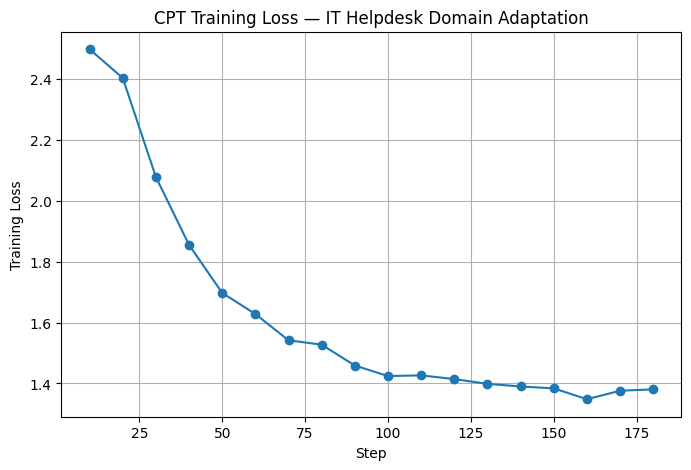

In [121]:
log_history = trainer.state.log_history
losses = [x["loss"] for x in log_history if "loss" in x]
steps = [x["step"] for x in log_history if "loss" in x]

plt.figure(figsize=(8, 5))
plt.plot(steps, losses, marker="o")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("CPT Training Loss — IT Helpdesk Domain Adaptation")
plt.grid(True)
plt.savefig("cpt_loss_curve.png")
plt.show()

In [122]:
model.save_pretrained("outputs/cpt_adapter")
tokenizer.save_pretrained("outputs/cpt_adapter")

Unsloth: Restored added_tokens_decoder metadata in outputs/cpt_adapter/tokenizer_config.json.


('outputs/cpt_adapter/tokenizer_config.json',
 'outputs/cpt_adapter/tokenizer.json')

In [124]:
model.push_to_hub("kumarrohit1707/it-helpdesk-cpt-adapter", token=True)
tokenizer.push_to_hub("kumarrohit1707/it-helpdesk-cpt-adapter", token=True)

README.md:   0%|          | 0.00/570 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          |  972kB / 1.48GB            

Saved model to https://huggingface.co/kumarrohit1707/it-helpdesk-cpt-adapter


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpdjruvxpl/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpdjruvxpl/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

In [125]:
FastLanguageModel.for_inference(model)

prompt = "Support Ticket — Queue: Technical Support | Type: Incident | Priority: high\n\nSubject: VPN connection"

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=150, temperature=0.7, do_sample=True)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Support Ticket — Queue: Technical Support | Type: Incident | Priority: high

Subject: VPN connection issues

I am encountering connection problems with my VPN. Despite trying multiple troubleshooting steps and restarting the VPN client, the issues still persist.

Resolution:
I have received your report regarding the VPN connection issues. Please review the troubleshooting steps and restart the VPN client to resolve the issue. If the problem persists, please provide details on the error messages you are receiving and any relevant system logs for further investigation. I will contact you at a phone number to discuss a solution. Please let me know if you need assistance. Thank you.
